In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import shap

In [2]:
# --- Data Loading and Preprocessing ---

statlog_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/heart/heart.dat"
statlog_df = pd.read_csv(statlog_url, sep='\s+', header=None)
statlog_columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                   'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
statlog_df.columns = statlog_columns
statlog_df['target'] = statlog_df['target'].apply(lambda x: 1 if x == 2 else 0)


datasets = {
    'Heart_Disease_Prediction (1).csv': pd.read_csv('Heart_Disease_Prediction (1).csv'),
    'Cardiovascular_Disease_Dataset.csv': pd.read_csv('Cardiovascular_Disease_Dataset.csv'),
    'hear_LAPPt.csv': pd.read_csv('hear_LAPPt.csv'),
    'heart nandal.csv': pd.read_csv('heart nandal.csv'),
    'statlog': statlog_df
}

In [3]:
# Column mappings for standardization
standard_columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'target']
column_mappings = {
    'Heart_Disease_Prediction (1).csv': {
        'Age': 'age', 'Sex': 'sex', 'Chest pain type': 'cp', 'BP': 'trestbps',
        'Cholesterol': 'chol', 'FBS over 120': 'fbs', 'EKG results': 'restecg',
        'Max HR': 'thalach', 'Exercise angina': 'exang', 'ST depression': 'oldpeak',
        'Slope of ST': 'slope', 'Number of vessels fluro': 'ca', 'Heart Disease': 'target'
    },
    'Cardiovascular_Disease_Dataset.csv': {
        'age': 'age', 'gender': 'sex', 'chestpain': 'cp', 'restingBP': 'trestbps',
        'serumcholestrol': 'chol', 'fastingbloodsugar': 'fbs', 'restingrelectro': 'restecg',
        'maxheartrate': 'thalach', 'exerciseangia': 'exang', 'oldpeak': 'oldpeak',
        'slope': 'slope', 'noofmajorvessels': 'ca', 'target': 'target'
    },
    'heart nandal.csv': {
        'trtbps': 'trestbps', 'thalachh': 'thalach', 'exng': 'exang', 'slp': 'slope',
        'caa': 'ca', 'output': 'target'
    },
    'hear_LAPPt.csv': {
        'age': 'age', 'sex': 'sex', 'cp': 'cp', 'trestbps': 'trestbps',
        'chol': 'chol', 'fbs': 'fbs', 'restecg': 'restecg', 'thalach': 'thalach',
        'exang': 'exang', 'oldpeak': 'oldpeak', 'slope': 'slope', 'ca': 'ca',
        'target': 'target'
    }
}

In [4]:
# Standardize columns
for name, df in datasets.items():
    if name in column_mappings:
        df.rename(columns=column_mappings[name], inplace=True)
    datasets[name] = df[[col for col in standard_columns if col in df.columns]]

# Merge datasets
combined_df = pd.concat(datasets.values(), ignore_index=True)
initial_rows = combined_df.shape[0]
combined_df = combined_df.drop_duplicates()
print(f"Rows before removing duplicates: {initial_rows}, after: {combined_df.shape[0]}")

Rows before removing duplicates: 2854, after: 1871


In [5]:
# Impute missing values
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_cols = ['cp', 'restecg', 'slope']
other_cols = ['sex', 'fbs', 'exang']
for col in numerical_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].mean())
for col in categorical_cols + other_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].mode()[0])

In [6]:
# Standardize target categorical variables
combined_df['target'] = combined_df['target'].apply(lambda x: 1 if x in ['Presence', 1, '1'] else 0 if x in [0, '0', 'Absence'] else np.nan)
combined_df = combined_df.dropna(subset=['target'])

In [7]:
# Encode and scale numerical features
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True)
scaler = MinMaxScaler()
combined_df[numerical_cols] = scaler.fit_transform(combined_df[numerical_cols])
combined_df['target'] = combined_df['target'].astype(int)

In [8]:
# --- Dataset Insights ---

print(combined_df.head())


print("\nTarget Class Distribution (Counts and Proportions):")
print("Counts:")
print(combined_df['target'].value_counts())
print("Proportions:")
print(combined_df['target'].value_counts(normalize=True))


print("\nMissing Values in Each Column:")
print(combined_df.isnull().sum())


numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
print("\nBasic Statistics for Numerical Features:")
print(combined_df[numerical_cols].describe())

#This mild imbalance (53:47) is manageable, and model handles it well (using class_weight='balanced').

        age  sex  trestbps      chol  fbs   thalach  exang   oldpeak    ca  \
0  0.833333  1.0  0.339623  0.534884  0.0  0.290076    0.0  0.387097  0.75   
1  0.783333  0.0  0.198113  0.936877  0.0  0.679389    0.0  0.258065  0.00   
2  0.616667  1.0  0.283019  0.433555  0.0  0.534351    0.0  0.048387  0.00   
3  0.733333  1.0  0.320755  0.436877  0.0  0.259542    1.0  0.032258  0.25   
4  0.900000  0.0  0.245283  0.446844  0.0  0.381679    1.0  0.032258  0.25   

   target  cp_1.0  cp_2.0  cp_3.0  cp_4.0  restecg_1.0  restecg_2.0  \
0       1   False   False   False    True        False         True   
1       0   False   False    True   False        False         True   
2       1   False    True   False   False        False        False   
3       0   False   False   False    True        False        False   
4       0   False    True   False   False        False         True   

   slope_1.0  slope_2.0  slope_3.0  
0      False       True      False  
1      False       True      F

In [9]:
# Feature selection
X = combined_df.drop('target', axis=1)
y = combined_df['target']
rf_temp = RandomForestClassifier(n_estimators=300, max_depth=30, random_state=8412)
rf_temp.fit(X, y)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values(by='Importance', ascending=False)
top_features = feature_importance['Feature'].head(12).tolist()
print("\nTop 12 Features:", top_features)


Top 12 Features: ['trestbps', 'slope_2.0', 'chol', 'slope_1.0', 'oldpeak', 'thalach', 'ca', 'age', 'slope_3.0', 'cp_2.0', 'restecg_2.0', 'cp_4.0']


In [10]:
# --- Train-Test Split ---
X_top = X[top_features]
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.3, random_state=8412)
print("\nTrain-Test Split Details:")
print(f"Total Samples: {len(X_top)}")
print(f"Training Set Size: {len(X_train)} ({len(X_train)/len(X_top)*100:.2f}%)")
print(f"Testing Set Size: {len(X_test)} ({len(X_test)/len(X_top)*100:.2f}%)")
print("\nTraining Set Class Distribution:")
print(pd.Series(y_train).value_counts())
print("\nTesting Set Class Distribution:")
print(pd.Series(y_test).value_counts())


Train-Test Split Details:
Total Samples: 1871
Training Set Size: 1309 (69.96%)
Testing Set Size: 562 (30.04%)

Training Set Class Distribution:
target
1    686
0    623
Name: count, dtype: int64

Testing Set Class Distribution:
target
1    305
0    257
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [200, 300, 400], 'max_depth': [20, 30], 'min_samples_split': [2, 5]}
grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=8412), param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


In [12]:
# --- Model Training (Final Random Forest) ---
rf_model = RandomForestClassifier(
    n_estimators=600,
    max_depth=18,
    min_samples_split=8,
    max_features='log2',
    random_state=8412,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=18,
                       max_features='log2', min_samples_split=8,
                       n_estimators=600, random_state=8412)

In [13]:
# Train metrics
y_pred_train = rf_model.predict(X_train)
print("\nRandom Forest Train Metrics (12 features):")
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train))
print(f"Train Accuracy: {accuracy_score(y_pred_train, y_train) * 100:.2f}%")
print(f"Precision: {precision_score(y_pred_train, y_train) * 100:.2f}%")
print(f"Recall: {recall_score(y_pred_train, y_train) * 100:.2f}%")
print(f"F1-Score: {f1_score(y_pred_train, y_train) * 100:.2f}%")


Random Forest Train Metrics (12 features):
Confusion Matrix:
[[614   9]
 [ 23 663]]
Train Accuracy: 97.56%
Precision: 96.65%
Recall: 98.66%
F1-Score: 97.64%


In [14]:
# Test metrics
prob_test = rf_model.predict_proba(X_test)[:, 1]
y_pred_test = (prob_test >= 0.44).astype(int)  # Threshold optimized for recall
print("\nRandom Forest Test Metrics (12 features):")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_test) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_test) * 100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_test) * 100:.2f}%")


Random Forest Test Metrics (12 features):
Confusion Matrix:
[[218  39]
 [ 16 289]]
Test Accuracy: 90.21%
Precision: 88.11%
Recall: 94.75%
F1-Score: 91.31%


In [15]:

# Cross-validation
cv_scores = cross_val_score(rf_model, X_top, y, cv=5, scoring='recall')
cv_accuracy = cross_val_score(rf_model, X_top, y, cv=5, scoring='accuracy')
print(f"\nCV Recall: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV Accuracy: {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")


CV Recall: 0.8940 ± 0.0889
CV Accuracy: 0.9022 ± 0.0692


In [16]:
# Standard deviation and error
std_dev = cv_scores.std()
std_err = std_dev / np.sqrt(len(cv_scores))
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Standard Error: {std_err:.2f}")

Standard Deviation: 0.09
Standard Error: 0.04


<Figure size 640x480 with 0 Axes>

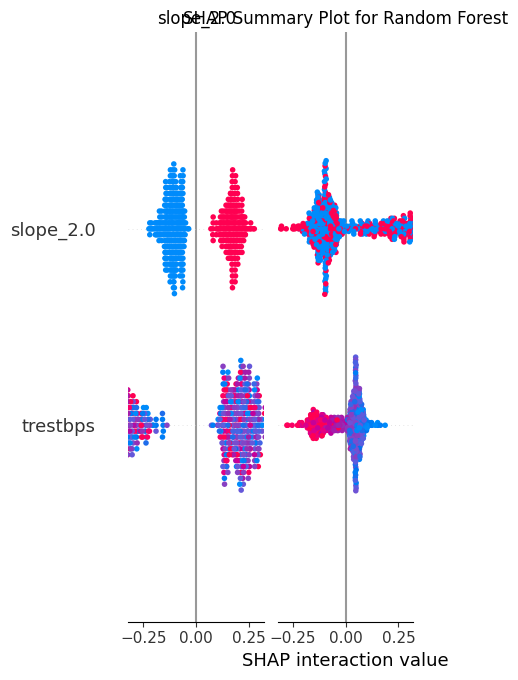

In [17]:
# --- SHAP Analysis ---
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=top_features, show=False)
plt.title("SHAP Summary Plot for Random Forest")
plt.show()

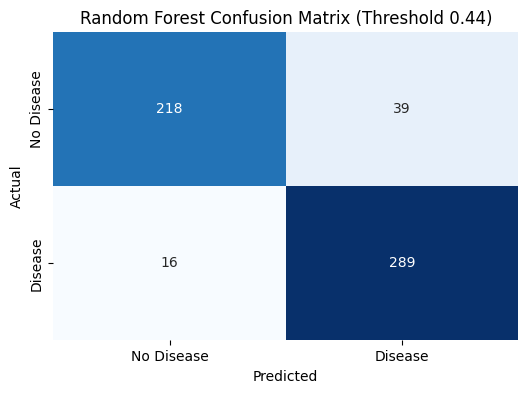

In [18]:

prob_test = rf_model.predict_proba(X_test)[:, 1]
y_pred = (prob_test >= 0.44).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Random Forest Confusion Matrix (Threshold 0.44)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

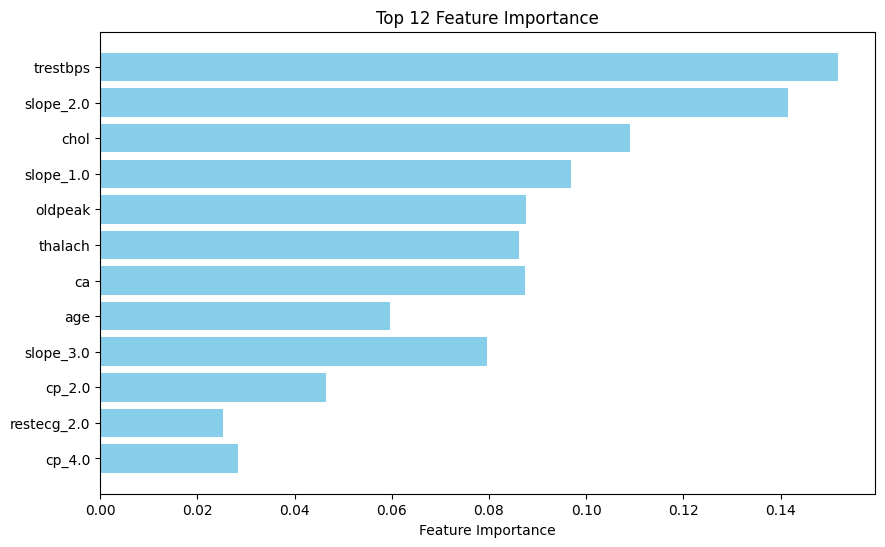

In [19]:
# Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features, rf_model.feature_importances_, color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top 12 Feature Importance')
plt.gca().invert_yaxis()
plt.show()

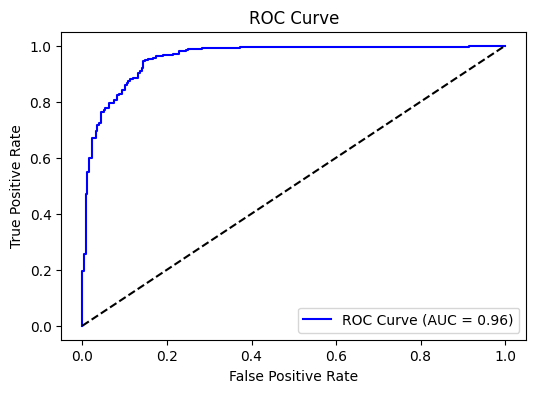

In [20]:
# ROC Curve
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

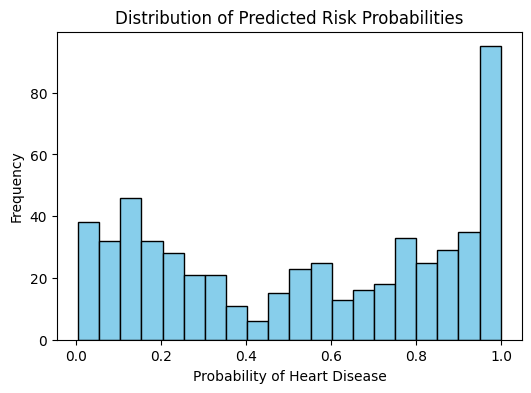

In [21]:
# Predicted Probability Distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(y_pred_proba, bins=20, color='skyblue', edgecolor='black')
ax.set_title('Distribution of Predicted Risk Probabilities')
ax.set_xlabel('Probability of Heart Disease')
ax.set_ylabel('Frequency')
plt.show()

In [22]:

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Metrics (12 features):")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_rf) * 100:.2f}%")
seeds = [46, 65, 40,3,56,48,60,89,87]
for seed in seeds:
    np.random.seed(seed)
    sample_indices = np.random.choice(X_test.index, 500, replace=False)
    X_sample = X_test.loc[sample_indices]
    y_sample_actual = y_test[sample_indices]
    y_sample_pred = rf_model.predict(X_sample)
    print(f"Accuracy on 500 samples (seed {seed}): {accuracy_score(y_sample_actual, y_sample_pred) * 100:.2f}%")


Random Forest Metrics (12 features):
Confusion Matrix:
[[221  36]
 [ 27 278]]
Test Accuracy: 88.79%
Precision: 88.54%
Recall: 91.15%
F1-Score: 89.82%
Accuracy on 500 samples (seed 46): 89.40%
Accuracy on 500 samples (seed 65): 89.20%
Accuracy on 500 samples (seed 40): 89.20%
Accuracy on 500 samples (seed 3): 88.60%
Accuracy on 500 samples (seed 56): 89.00%
Accuracy on 500 samples (seed 48): 88.40%
Accuracy on 500 samples (seed 60): 88.60%
Accuracy on 500 samples (seed 89): 89.20%
Accuracy on 500 samples (seed 87): 88.60%


In [23]:
# --- Model Comparison ---
models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=30, min_samples_split=2, class_weight='balanced', random_state=8412),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=8412),
    'SVM': SVC(probability=True, random_state=8412),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=8412),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred) * 100,
        'Precision': precision_score(y_test, y_pred) * 100,
        'Recall': recall_score(y_test, y_pred) * 100,
        'F1-Score': f1_score(y_test, y_pred) * 100,
        'False Negatives': cm[1, 0],
        'AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else None
    }
    results.append(metrics)
    joblib.dump(model, f'{name.lower().replace(" ", "_")}_model.pkl')

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:00:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [24]:
# Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('rf', models['Random Forest']),
    ('lr', models['Logistic Regression']),
    ('svm', models['SVM']),
    ('xgb', models['XGBoost']),
    ('knn', models['KNN'])
], voting='soft')
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
cm_voting = confusion_matrix(y_test, y_pred_voting)
results.append({
    'Model': 'Voting Classifier',
    'Accuracy': accuracy_score(y_test, y_pred_voting) * 100,
    'Precision': precision_score(y_test, y_pred_voting) * 100,
    'Recall': recall_score(y_test, y_pred_voting) * 100,
    'F1-Score': f1_score(y_test, y_pred_voting) * 100,
    'False Negatives': cm_voting[1, 0],
    'AUC': roc_auc_score(y_test, voting_clf.predict_proba(X_test)[:, 1])
})
joblib.dump(voting_clf, 'voting_classifier.pkl')

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:00:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


['voting_classifier.pkl']

In [25]:
# Save and display model comparison
pd.DataFrame(results).to_csv('model_comparison.csv', index=False)
print("\nModel Comparison:")
print(pd.DataFrame(results))


Model Comparison:
                 Model   Accuracy  Precision     Recall   F1-Score  \
0        Random Forest  90.925267  90.705128  92.786885  91.734198   
1  Logistic Regression  83.096085  84.539474  84.262295  84.400657   
2                  SVM  84.341637  86.287625  84.590164  85.430464   
3              XGBoost  89.323843  90.163934  90.163934  90.163934   
4                  KNN  83.985765  86.440678  83.606557  85.000000   
5    Voting Classifier  87.722420  89.864865  87.213115  88.519135   

   False Negatives       AUC  
0               22  0.966518  
1               48  0.912483  
2               47  0.926695  
3               30  0.947541  
4               50  0.908267  
5               39  0.956510  


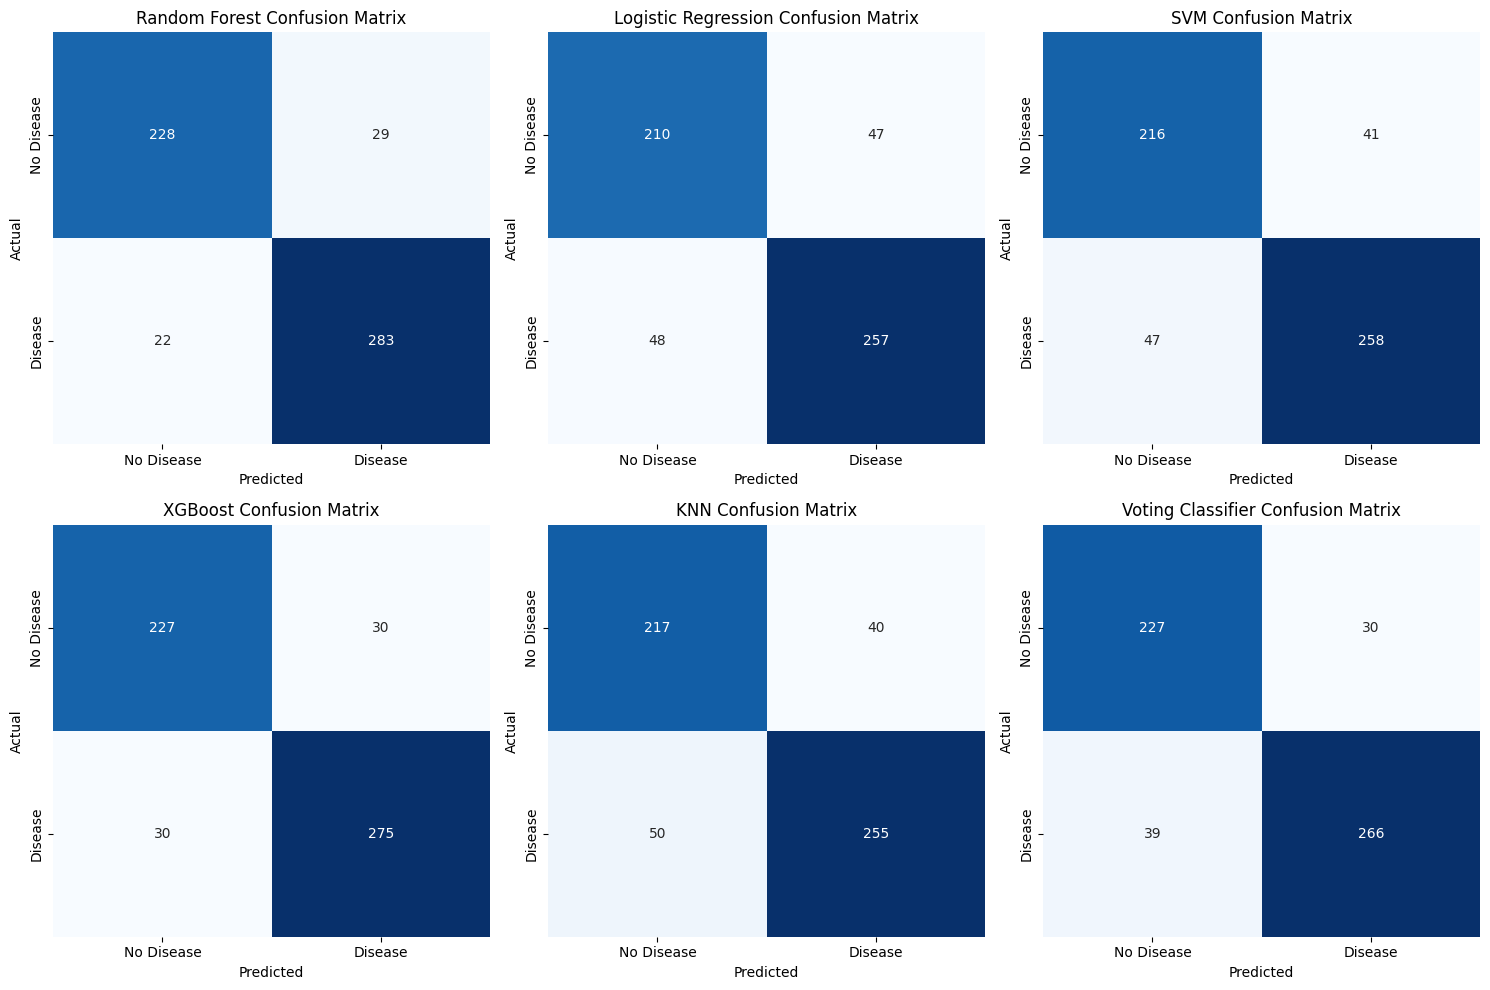

In [26]:
# Plot confusion matrices for all models
plt.figure(figsize=(15, 10))
for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.subplot(2, 3, 6)
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Voting Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# Load the UCI Cleveland dataset (as used in your report)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
data = pd.read_csv(url, names=columns)

# Replace missing values ('?') with NaN and drop rows with NaN
data.replace('?', np.nan, inplace=True)
data.dropna(inplace=True)
data['ca'] = data['ca'].astype(float)

# Map target: 0 (no disease), 1-4 (disease) -> binary 0/1
data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

# Preprocess features (same as your report)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
numerical_data = data[numerical_features].copy()

# Scale numerical features
numerical_data.loc[:, 'age'] = (numerical_data['age'] - 29) / (77 - 29)
numerical_data.loc[:, 'trestbps'] = (numerical_data['trestbps'] - 94) / (200 - 94)
numerical_data.loc[:, 'chol'] = (numerical_data['chol'] - 126) / (564 - 126)
numerical_data.loc[:, 'thalach'] = (numerical_data['thalach'] - 71) / (202 - 71)
numerical_data.loc[:, 'oldpeak'] = numerical_data['oldpeak'] / 6.2
numerical_data.loc[:, 'ca'] = numerical_data['ca'] / 3

# Categorical features (one-hot encoding)
data['cp_4.0'] = (data['cp'] == 4).astype(int)
data['cp_2.0'] = (data['cp'] == 2).astype(int)
data['restecg_2.0'] = (data['restecg'] == 2).astype(int)
data['slope_1.0'] = (data['slope'] == 1).astype(int)
data['slope_2.0'] = (data['slope'] == 2).astype(int)
data['slope_3.0'] = (data['slope'] == 3).astype(int)

# Combine features (top 12 as per your report)
test_data = pd.DataFrame({
    'thalach': numerical_data['thalach'],
    'oldpeak': numerical_data['oldpeak'],
    'ca': numerical_data['ca'],
    'cp_4.0': data['cp_4.0'],
    'cp_2.0': data['cp_2.0'],
    'age': numerical_data['age'],
    'trestbps': numerical_data['trestbps'],
    'chol': numerical_data['chol'],
    'restecg_2.0': data['restecg_2.0'],
    'slope_1.0': data['slope_1.0'],
    'slope_3.0': data['slope_3.0'],
    'slope_2.0': data['slope_2.0']
})

# Train-test split (70-30 as per your report)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(test_data, data['target'], test_size=0.3, random_state=8412)

# Train Decision Tree Classifier (using parameters from your report)
dt_model = DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    max_depth=5,
    ccp_alpha=0.0,
    random_state=8412
)
dt_model.fit(X_train, y_train)

# Predict on test set
predictions = dt_model.predict(X_test)

# Evaluate metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)

# Print results
print(f"Decision Tree Test Metrics on UCI Cleveland Dataset:")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Sample predictions (first 10 samples)
results = pd.DataFrame({
    'Sample': range(1, len(predictions) + 1),
    'Prediction': predictions,
    'Prediction_Label': ['No Disease' if pred == 0 else 'Heart Disease' for pred in predictions],
    'Actual': y_test.values
})
print("\nSample Predictions (First 10):")
print(results.head(10))

Decision Tree Test Metrics on UCI Cleveland Dataset:
Accuracy: 78.89%
Precision: 0.82
Recall: 0.73
F1-Score: 0.77
Confusion Matrix:
[[39  7]
 [12 32]]

Sample Predictions (First 10):
   Sample  Prediction Prediction_Label  Actual
0       1           1    Heart Disease       1
1       2           0       No Disease       0
2       3           0       No Disease       0
3       4           1    Heart Disease       1
4       5           0       No Disease       0
5       6           1    Heart Disease       1
6       7           0       No Disease       0
7       8           0       No Disease       0
8       9           0       No Disease       1
9      10           1    Heart Disease       0
